<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
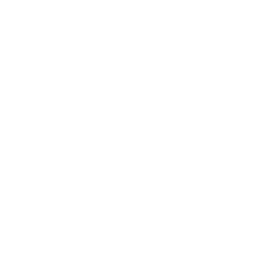
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Documentazione dello schema di annotazione delle varianti genomiche</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Bioinformatica / Gestione dei dati di genomica clinica &nbsp;|&nbsp; Marzo 2026</p>
</div>
</div>
</div>

## Sintesi esecutiva

Documentare lo schema dei dataset di annotazione delle varianti in stile VCF utilizzati in una pipeline di genomica clinica. Usare PROC CONTENTS per catalogare tutti i campi di annotazione — coordinate genomiche, frequenze alleliche, effetti funzionali previsti, classificazioni ClinVar e metriche di qualità — assicurando che gli strumenti a valle di interpretazione delle varianti ACMG ricevano input correttamente tipizzati ed etichettati. Circa 5.000 record di varianti con oltre 20 colonne di annotazione vengono ispezionati per l'integrità dello schema prima del passaggio alla pipeline.

## Fonti dei dati

| Fonte | Descrizione | Record |
|--------|-------------|--------|
| VARIANT_ANNOTATIONS | Varianti annotate derivate da VCF | ~5.000 |
| GENE_PANEL | Definizioni del pannello di geni target | ~150 geni |
| QUALITY_METRICS | Controllo qualità del sequenziamento per campione | ~50 campioni |

---

In [1]:
/* --------------------------------------------------------
   Genera un dataset di annotazione varianti in stile VCF
   5.000 varianti con campi di annotazione clinica
   -------------------------------------------------------- */
DATI variant_annotations;
    CHIAMARE streaminit(42);
    LUNGHEZZA variant_id $20 chromosome $5 position 8
           ref_allele $10 alt_allele $10 gene_symbol $15
           transcript_id $20 consequence $30
           impact $10 hgvs_c $25 hgvs_p $25
           gnomad_af 8 clinvar_class $25 clinvar_id $12
           sift_score 8 sift_pred $15
           polyphen_score 8 polyphen_pred $15
           cadd_phred 8 revel_score 8
           genotype $5 allele_depth 8 read_depth 8
           qual_score 8 filter_status $10;
    ETICHETTA variant_id='Identificatore variante'
          chromosome='Cromosoma'
          position='Posizione genomica (GRCh38)'
          ref_allele='Allele di riferimento'
          alt_allele='Allele alternativo'
          gene_symbol='Simbolo genico HGNC'
          transcript_id='ID trascritto Ensembl'
          consequence='Conseguenza (Sequence Ontology)'
          impact='Livello di impatto previsto'
          hgvs_c='Notazione HGVS codificante'
          hgvs_p='Notazione HGVS proteica'
          gnomad_af='Frequenza allelica gnomAD'
          clinvar_class='Classificazione ClinVar'
          clinvar_id='Accessione ClinVar'
          sift_score='Punteggio SIFT'
          sift_pred='Predizione SIFT'
          polyphen_score='Punteggio PolyPhen-2'
          polyphen_pred='Predizione PolyPhen-2'
          cadd_phred='Punteggio CADD Phred'
          revel_score='Punteggio REVEL (ensemble)'
          genotype='Genotipo del campione'
          allele_depth='Profondità allele alternativo'
          read_depth='Profondità di lettura totale'
          qual_score='Punteggio di qualità variante'
          filter_status='Stato del filtro';
    VETTORE genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    VETTORE conseqs[6] $30 _temporary_ ('missense_variant'
        'synonymous_variant' 'frameshift_variant'
        'stop_gained' 'splice_donor_variant' 'intron_variant');
    VETTORE impacts[6] $10 _temporary_ ('MODERATE' 'LOW' 'HIGH'
        'HIGH' 'HIGH' 'MODIFIER');
    VETTORE cv_classes[5] $25 _temporary_ ('Pathogenic'
        'Likely_pathogenic' 'Uncertain_significance'
        'Likely_benign' 'Benign');
    VETTORE refs[4] $1 _temporary_ ('A' 'C' 'G' 'T');
    VETTORE gts[3] $5 _temporary_ ('0/1' '1/1' '0/0');
    FARE i = 1 FINO_A 5000;
        variant_id = cat('VAR-', PUT(i, z8.));
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', PUT(chr_num, 2.));
        position = int(rand('uniform') * 200000000) + 10000;
        r_idx = int(rand('uniform') * 4) + 1;
        a_idx = mod(r_idx, 4) + 1;
        ref_allele = refs[r_idx];
        alt_allele = refs[a_idx];
        g_idx = int(rand('uniform') * 15) + 1;
        gene_symbol = genes[g_idx];
        transcript_id = cat('ENST00000', PUT(int(rand('uniform') * 99999) + 100000, z6.));
        c_idx = int(rand('uniform') * 6) + 1;
        consequence = conseqs[c_idx];
        impact = impacts[c_idx];
        codon_pos = int(rand('uniform') * 2000) + 1;
        hgvs_c = cat('c.', PUT(codon_pos, 4.), ref_allele, '>', alt_allele);
        SE_COND c_idx <= 2 ALLORA
            hgvs_p = cat('p.', PUT(int(rand('uniform') * 800) + 1, 4.));
        ALTRIMENTI hgvs_p = 'p.?';
        gnomad_af = round(rand('beta', 0.5, 500), 0.000001);
        cv_idx = int(rand('uniform') * 5) + 1;
        clinvar_class = cv_classes[cv_idx];
        clinvar_id = cat('RCV', PUT(int(rand('uniform') * 900000) + 100000, z6.));
        sift_score = round(rand('uniform'), 0.001);
        SE_COND sift_score < 0.05 ALLORA sift_pred = 'DELETERIOUS';
        ALTRIMENTI sift_pred = 'TOLERATED';
        polyphen_score = round(rand('uniform'), 0.001);
        SE_COND polyphen_score > 0.908 ALLORA polyphen_pred = 'PROB_DAMAGING';
        ALTRIMENTI SE_COND polyphen_score > 0.446 ALLORA polyphen_pred = 'POSS_DAMAGING';
        ALTRIMENTI polyphen_pred = 'BENIGN';
        cadd_phred = round(rand('uniform') * 40, 0.01);
        revel_score = round(rand('uniform'), 0.001);
        gt_idx = int(rand('uniform') * 3) + 1;
        genotype = gts[gt_idx];
        read_depth = int(rand('uniform') * 200) + 20;
        allele_depth = int(read_depth * (0.3 + rand('uniform') * 0.4));
        qual_score = round(rand('uniform') * 5000 + 100, 0.1);
        filter_status = ifc(qual_score > 500, 'PASS', 'LOW_QUAL');
        USCITA;
    FINE;
    RIMUOVERE i chr_num r_idx a_idx g_idx c_idx cv_idx gt_idx codon_pos;
ESEGUIRE;


NOTE: DATA variant_annotations

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote variant_annotations (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  3.11 seconds
  cpu   3.11 seconds


In [2]:
/* --------------------------------------------------------
   Genera le definizioni del pannello di geni target
   -------------------------------------------------------- */
DATI gene_panel;
    CHIAMARE streaminit(42);
    LUNGHEZZA gene_symbol $15 gene_name $60 chromosome $5
           start_pos 8 end_pos 8 panel_name $30
           disease_association $50 inheritance $5;
    ETICHETTA gene_symbol='Simbolo genico HGNC'
          gene_name='Nome completo del gene'
          chromosome='Cromosoma'
          start_pos='Posizione iniziale del gene'
          end_pos='Posizione finale del gene'
          panel_name='Pannello genico clinico'
          disease_association='Malattia associata'
          inheritance='Modello di ereditarietà';
    VETTORE genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    VETTORE gnames[15] $60 _temporary_ (
        'BRCA1 DNA Repair Associated'
        'BRCA2 DNA Repair Associated'
        'Tumor Protein P53'
        'Epidermal Growth Factor Receptor'
        'KRAS Proto-Oncogene'
        'PI3-Kinase Catalytic Subunit Alpha'
        'Phosphatase and Tensin Homolog'
        'APC Regulator of WNT Signaling'
        'MutL Homolog 1'
        'MutS Homolog 2'
        'ATM Serine/Threonine Kinase'
        'Checkpoint Kinase 2'
        'Partner and Localizer of BRCA2'
        'RAD51 Paralog C'
        'RAD51 Paralog D');
    VETTORE diseases[15] $50 _temporary_ (
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Li-Fraumeni Syndrome'
        'Non-Small Cell Lung Cancer'
        'Colorectal Cancer'
        'Breast Cancer'
        'Cowden Syndrome'
        'Familial Adenomatous Polyposis'
        'Lynch Syndrome'
        'Lynch Syndrome'
        'Ataxia-Telangiectasia'
        'Li-Fraumeni Syndrome'
        'Hereditary Breast Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer');
    VETTORE inhrt[15] $5 _temporary_ ('AD' 'AD' 'AD' 'AD' 'AD'
        'AD' 'AD' 'AD' 'AD' 'AD' 'AR' 'AD' 'AD' 'AD' 'AD');
    FARE g = 1 FINO_A 15;
        gene_symbol = genes[g];
        gene_name = gnames[g];
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', PUT(chr_num, 2.));
        start_pos = int(rand('uniform') * 150000000) + 1000000;
        end_pos = start_pos + int(rand('uniform') * 100000) + 5000;
        panel_name = 'HEREDITARY_CANCER_V3';
        disease_association = diseases[g];
        inheritance = inhrt[g];
        USCITA;
    FINE;
    RIMUOVERE g chr_num;
ESEGUIRE;


NOTE: DATA gene_panel


NOTE: Wrote gene_panel (15 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [3]:
/* --------------------------------------------------------
   Genera le metriche di qualità del sequenziamento per campione
   -------------------------------------------------------- */
DATI quality_metrics;
    CHIAMARE streaminit(42);
    LUNGHEZZA sample_id $15 run_id $12 platform $15
           mean_coverage 8 pct_target_20x 8 pct_target_100x 8
           total_variants 8 ti_tv_ratio 8 het_hom_ratio 8
           contamination_est 8 qc_status $10;
    ETICHETTA sample_id='Identificatore campione'
          run_id='ID run di sequenziamento'
          platform='Piattaforma di sequenziamento'
          mean_coverage='Copertura media del target'
          pct_target_20x='Percentuale basi >= 20x'
          pct_target_100x='Percentuale basi >= 100x'
          total_variants='Varianti totali chiamate'
          ti_tv_ratio='Rapporto transizioni/trasversioni'
          het_hom_ratio='Rapporto Het/Hom'
          contamination_est='Contaminazione stimata'
          qc_status='Esito QC (Pass/Fail)';
    FARE s = 1 FINO_A 50;
        sample_id = cat('SAMP-', PUT(s, z6.));
        run_id = cat('RUN-', PUT(int((s - 1) / 10) + 1, z4.));
        platform = 'ILLUMINA_NOVA';
        mean_coverage = round(250 + rand('normal') * 50, 0.1);
        pct_target_20x = round(MIN(99.5, 95 + rand('uniform') * 4.5), 0.01);
        pct_target_100x = round(MIN(98, 85 + rand('uniform') * 13), 0.01);
        total_variants = int(rand('uniform') * 2000) + 3000;
        ti_tv_ratio = round(2.0 + rand('normal') * 0.15, 0.01);
        het_hom_ratio = round(1.5 + rand('normal') * 0.2, 0.01);
        contamination_est = round(MAX(0, rand('uniform') * 0.02), 0.0001);
        SE_COND mean_coverage < 150 O_LOG pct_target_20x < 95
            O_LOG contamination_est > 0.015 ALLORA qc_status = 'FAIL';
        ALTRIMENTI qc_status = 'PASS';
        USCITA;
    FINE;
    RIMUOVERE s;
ESEGUIRE;


NOTE: DATA quality_metrics


NOTE: Wrote quality_metrics (50 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                   Impatto della variante per classificazione ClinVar                                   

                                                   The FREQ Procedure

Table of Livello di impatto previsto by Classificazione ClinVar

Livello di impatto previsto |                Benign |         Likely_benign |     Likely_pathogenic |            Pathogenic |Uncertain_significance |                  Total
----------------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------
HIGH                        |                     9 |                    10 |                    19 |                    12 |                    12 |                     62
                            |                  9.00 |                 10.00 |                 19.00 |                 12.00 |                 12.00 |                  62.00
                            |                 14.5


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_impact_clinvar_class.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


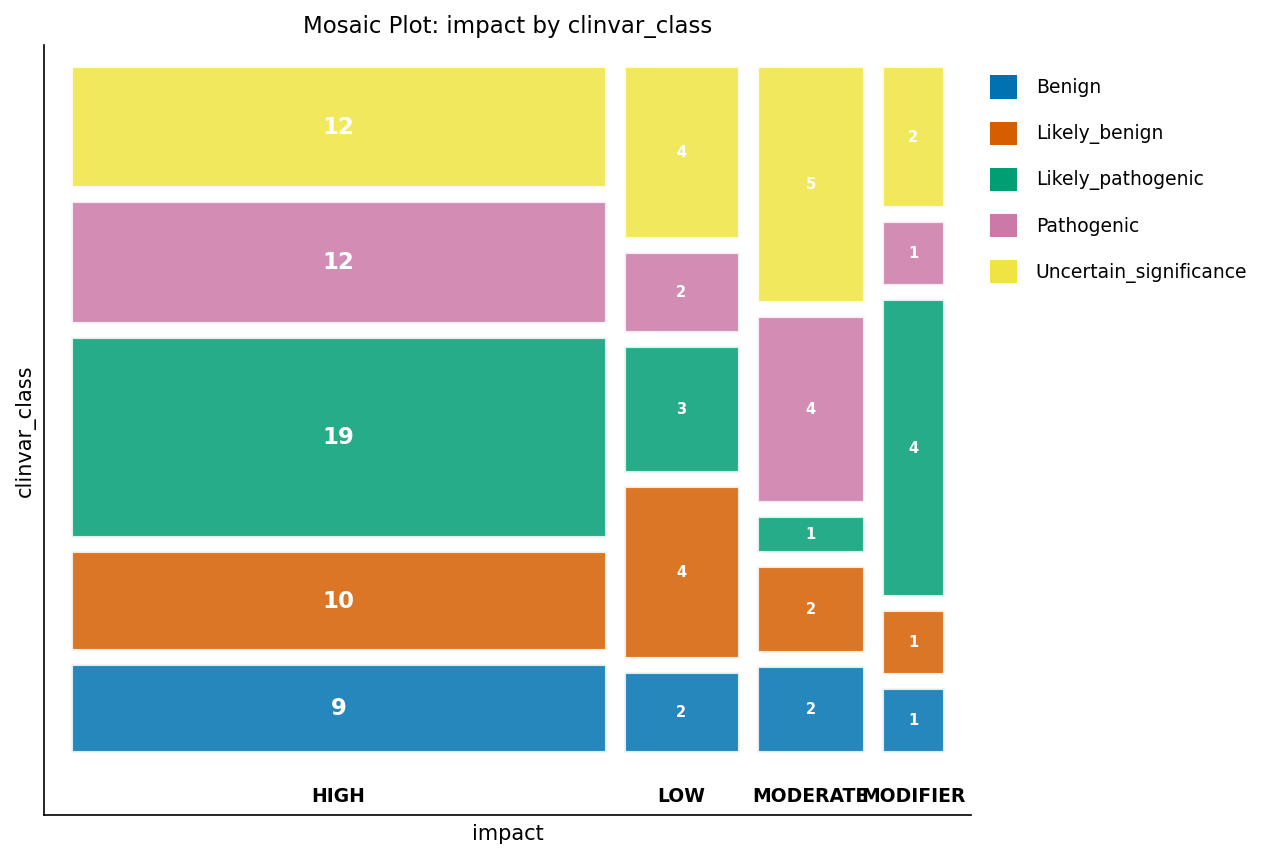

In [4]:
/* --------------------------------------------------------
   Riepilogo di base dell'annotazione delle varianti
   -------------------------------------------------------- */
PROCEDURA FREQUENZE DATI=variant_annotations;
    TABLES impact * clinvar_class / nocum;
    ETICHETTA impact='Livello di impatto previsto'
          clinvar_class='Classificazione ClinVar';
    TITOLO 'Impatto della variante per classificazione ClinVar';
ESEGUIRE;

PROCEDURA MEDIE DATI=quality_metrics n mean MIN MAX;
    VARIABILE mean_coverage ti_tv_ratio contamination_est;
    ETICHETTA mean_coverage='Copertura media del target'
          ti_tv_ratio='Rapporto transizioni/trasversioni'
          contamination_est='Contaminazione stimata';
    TITOLO 'Riepilogo delle metriche di qualità del sequenziamento';
ESEGUIRE;

---

                                 Riepilogo delle metriche di qualità del sequenziamento                                 

                                 Riepilogo delle metriche di qualità del sequenziamento                                 




NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=schema_lengths created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: DATA schema_lengths


NOTE: Read 25 rows from schema_lengths.
NOTE: Wrote schema_lengths (25 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=schema_lengths

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


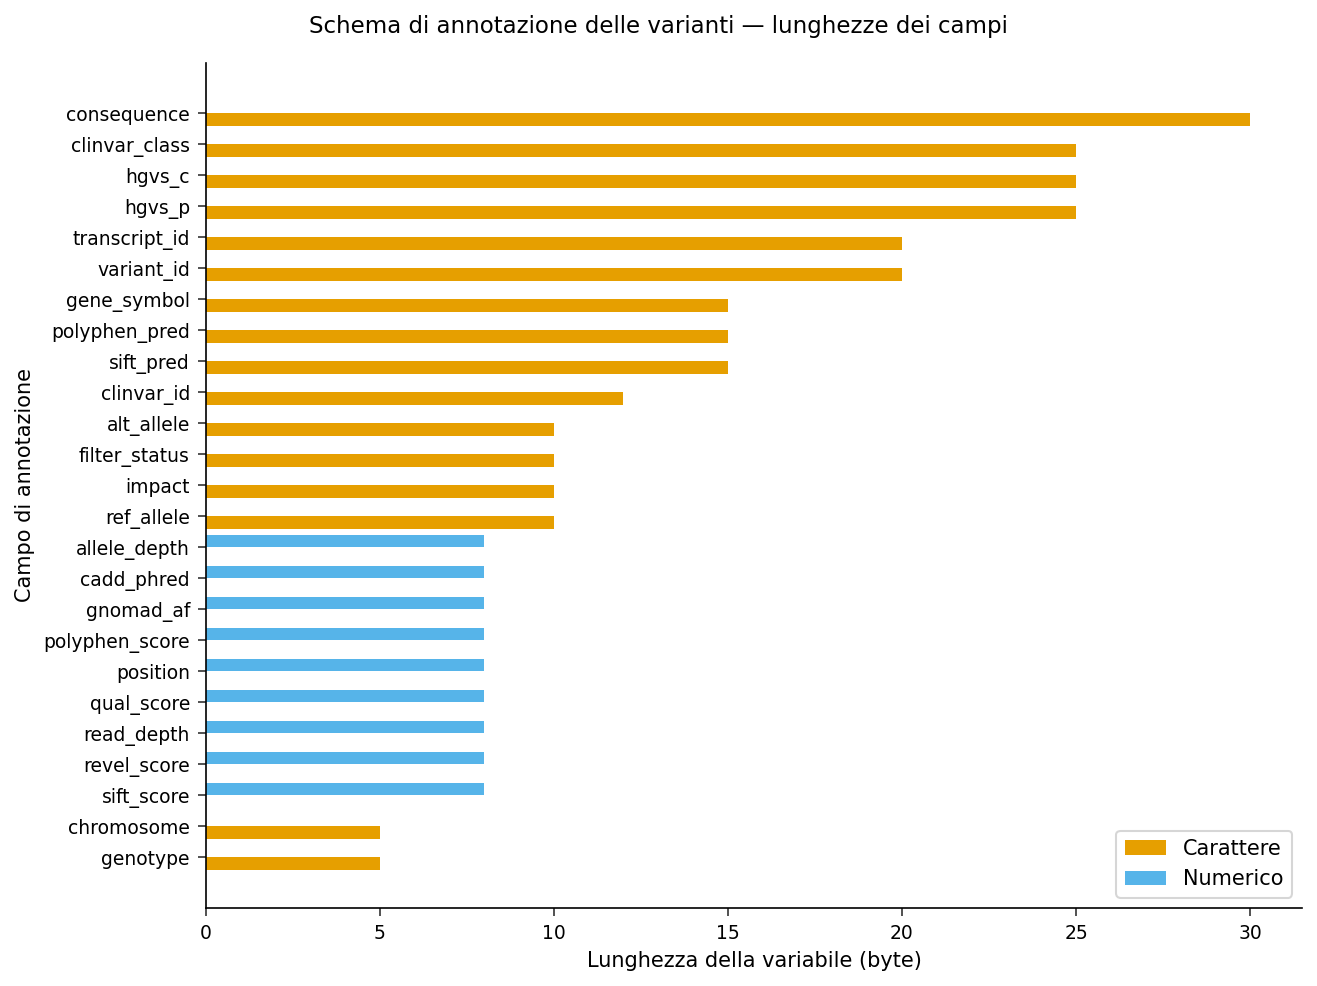

In [5]:
/* --------------------------------------------------------
   Distribuzione di tipo e lunghezza delle variabili.
   Cattura i metadati dello schema di annotazione con PROC
   CONTENTS OUT=, poi traccia le lunghezze dei campi per
   tipo. I codici TYPE mappano 1 -> Numerico, 2 -> Carattere
   per la legenda.
   -------------------------------------------------------- */
PROCEDURA CONTENUTO DATI=variant_annotations out=schema_lengths NOPRINT;
ESEGUIRE;

DATI schema_lengths;
    IMPOSTARE schema_lengths;
    LUNGHEZZA type_label $9;
    SE_COND TYPE = 1 ALLORA type_label = 'Numerico';
    ALTRIMENTI type_label = 'Carattere';
ESEGUIRE;

PROCEDURA SGPLOT DATI=schema_lengths;
    HBAR NAME / RESPONSE=LUNGHEZZA GROUP=type_label
        CATEGORYORDER=respdesc;
    XAXIS ETICHETTA='Lunghezza della variabile (byte)';
    YAXIS ETICHETTA='Campo di annotazione';
    TITOLO 'Schema di annotazione delle varianti — lunghezze dei campi';
ESEGUIRE;

---

In [6]:
/* --------------------------------------------------------
   PROC CONTENTS: documenta lo schema completo di annotazione
   delle varianti — tipi, lunghezze, etichette per tutti i 25
   campi. Cattura i metadati delle variabili con OUT= cosi che
   i passaggi a valle possano validare lo schema in modo
   programmatico.
   -------------------------------------------------------- */
PROCEDURA CONTENUTO DATI=variant_annotations out=variant_schema NOPRINT;
ESEGUIRE;

PROCEDURA STAMPARE DATI=variant_schema ETICHETTA;
    VARIABILE NAME TYPE LUNGHEZZA VARNUM ETICHETTA;
    ETICHETTA NAME='Nome campo' TYPE='Tipo' LUNGHEZZA='Lunghezza'
          VARNUM='Posizione' ETICHETTA='Etichetta';
    TITOLO 'Dataset di annotazione delle varianti — schema completo';
ESEGUIRE;

                                 Riepilogo delle metriche di qualità del sequenziamento                                 

                                Dataset di annotazione delle varianti — schema completo                                 

  Obs      Nome campo  Tipo  Lunghezza  Posizione                        Etichetta
    1  allele_depth       1          8         22  Profondità allele alternativo
    2  alt_allele         2         10          5  Allele alternativo
    3  cadd_phred         1          8         19  Punteggio CADD Phred
    4  chromosome         2          5          2  Cromosoma
    5  clinvar_class      2         25         13  Classificazione ClinVar
    6  clinvar_id         2         12         14  Accessione ClinVar
    7  consequence        2         30          8  Conseguenza (Sequence Ontology)
    8  filter_status      2         10         25  Stato del filtro
    9  gene_symbol        2         15          6  Simbolo genico HGNC
   10  genotype       


NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=variant_schema created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: PROC PRINT data=variant_schema

NOTE: PROC PRINT completed: 25 observations printed, 5 variables


In [7]:
/* --------------------------------------------------------
   PROC CONTENTS: documenta lo schema del pannello genico
   -------------------------------------------------------- */
PROCEDURA CONTENUTO DATI=gene_panel out=panel_schema NOPRINT;
ESEGUIRE;

PROCEDURA STAMPARE DATI=panel_schema ETICHETTA;
    VARIABILE NAME TYPE LUNGHEZZA VARNUM ETICHETTA;
    ETICHETTA NAME='Nome campo' TYPE='Tipo' LUNGHEZZA='Lunghezza'
          VARNUM='Posizione' ETICHETTA='Etichetta';
    TITOLO 'Definizione del pannello genico — schema';
ESEGUIRE;

                                Dataset di annotazione delle varianti — schema completo                                 

                                        Definizione del pannello genico — schema                                        

  Obs           Nome campo  Tipo  Lunghezza  Posizione                    Etichetta
    1  chromosome              2          5          3  Cromosoma
    2  disease_association     2         50          7  Malattia associata
    3  end_pos                 1          8          5  Posizione finale del gene
    4  gene_name               2         60          2  Nome completo del gene
    5  gene_symbol             2         15          1  Simbolo genico HGNC
    6  inheritance             2          5          8  Modello di ereditarietà
    7  panel_name              2         30          6  Pannello genico clinico
    8  start_pos               1          8          4  Posizione iniziale del gene




NOTE: PROC CONTENTS data=gene_panel

NOTE: PROC CONTENTS: OUT=panel_schema created with 8 variables
NOTE: PROC CONTENTS: data=gene_panel obs=15 vars=8 (NOPRINT)
NOTE: PROC PRINT data=panel_schema

NOTE: PROC PRINT completed: 8 observations printed, 5 variables


In [8]:
/* --------------------------------------------------------
   PROC CONTENTS: documenta lo schema delle metriche di QC
   -------------------------------------------------------- */
PROCEDURA CONTENUTO DATI=quality_metrics out=qc_schema NOPRINT;
ESEGUIRE;

PROCEDURA STAMPARE DATI=qc_schema ETICHETTA;
    VARIABILE NAME TYPE LUNGHEZZA VARNUM ETICHETTA;
    ETICHETTA NAME='Nome campo' TYPE='Tipo' LUNGHEZZA='Lunghezza'
          VARNUM='Posizione' ETICHETTA='Etichetta';
    TITOLO 'Metriche di qualità del sequenziamento — schema';
ESEGUIRE;

                                        Definizione del pannello genico — schema                                        

                                    Metriche di qualità del sequenziamento — schema                                     

  Obs         Nome campo  Tipo  Lunghezza  Posizione                          Etichetta
    1  contamination_est     1          8         10  Contaminazione stimata
    2  het_hom_ratio         1          8          9  Rapporto Het/Hom
    3  mean_coverage         1          8          4  Copertura media del target
    4  pct_target_100x       1          8          6  Percentuale basi >= 100x
    5  pct_target_20x        1          8          5  Percentuale basi >= 20x
    6  platform              2         15          3  Piattaforma di sequenziamento
    7  qc_status             2         10         11  Esito QC (Pass/Fail)
    8  run_id                2         12          2  ID run di sequenziamento
    9  sample_id             2         15   


NOTE: PROC CONTENTS data=quality_metrics

NOTE: PROC CONTENTS: OUT=qc_schema created with 11 variables
NOTE: PROC CONTENTS: data=quality_metrics obs=50 vars=11 (NOPRINT)
NOTE: PROC PRINT data=qc_schema

NOTE: PROC PRINT completed: 11 observations printed, 5 variables


In [9]:
/* --------------------------------------------------------
   Validazione dello schema: verifica che i campi di
   annotazione soddisfino i requisiti della pipeline per
   l'interpretazione ACMG. Legge i metadati di PROC CONTENTS
   OUT=, dove TYPE=1 indica numerico e TYPE=2 indica carattere.
   -------------------------------------------------------- */
DATI schema_validation;
    IMPOSTARE variant_schema;
    LUNGHEZZA requirement $60 status $10;
    /* I campi di punteggio numerici devono essere numerici (TYPE=1) */
    SE_COND NAME IN ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        E_LOG TYPE ne 1 ALLORA FARE;
        requirement = 'Deve essere numerico per le soglie di punteggio';
        status = 'FALLITO';
    FINE;
    ALTRIMENTI SE_COND NAME IN ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        E_LOG TYPE = 1 ALLORA FARE;
        requirement = 'Tipo numerico confermato';
        status = 'SUPERATO';
    FINE;
    /* La classe ClinVar necessita di lunghezza carattere sufficiente */
    ALTRIMENTI SE_COND NAME = 'clinvar_class' E_LOG LUNGHEZZA < 25 ALLORA FARE;
        requirement = 'Minimo $25 per il testo completo di classificazione';
        status = 'FALLITO';
    FINE;
    ALTRIMENTI SE_COND NAME = 'clinvar_class' ALLORA FARE;
        requirement = 'Lunghezza carattere sufficiente';
        status = 'SUPERATO';
    FINE;
    /* Ogni campo deve avere un'etichetta per il dizionario dati */
    ALTRIMENTI SE_COND ETICHETTA = '' ALLORA FARE;
        requirement = 'Etichetta richiesta per il dizionario dati';
        status = 'FALLITO';
    FINE;
    ALTRIMENTI FARE;
        requirement = 'Validazione generale';
        status = 'SUPERATO';
    FINE;
ESEGUIRE;

PROCEDURA STAMPARE DATI=schema_validation ETICHETTA;
    VARIABILE NAME TYPE LUNGHEZZA ETICHETTA requirement status;
    ETICHETTA NAME='Nome campo' TYPE='Tipo' LUNGHEZZA='Lunghezza'
          ETICHETTA='Etichetta' requirement='Requisito' status='Esito';
    TITOLO 'Report di validazione dello schema per pipeline ACMG';
ESEGUIRE;

                                  Report di validazione dello schema per pipeline ACMG                                  

  Obs      Nome campo  Tipo  Lunghezza                        Etichetta                        Requisito     Esito
    1  allele_depth       1          8  Profondità allele alternativo    Tipo numerico confermato         SUPERATO
    2  alt_allele         2         10  Allele alternativo               Validazione generale             SUPERATO
    3  cadd_phred         1          8  Punteggio CADD Phred             Tipo numerico confermato         SUPERATO
    4  chromosome         2          5  Cromosoma                        Validazione generale             SUPERATO
    5  clinvar_class      2         25  Classificazione ClinVar          Lunghezza carattere sufficiente  SUPERATO
    6  clinvar_id         2         12  Accessione ClinVar               Validazione generale             SUPERATO
    7  consequence        2         30  Conseguenza (Sequence Ontology)  


NOTE: DATA schema_validation


NOTE: Read 25 rows from variant_schema.
NOTE: Wrote schema_validation (25 rows, 18 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=schema_validation

NOTE: PROC PRINT completed: 25 observations printed, 6 variables


---

### Interpretazione

Lo schema di annotazione delle varianti contiene 25 campi che spaziano tra coordinate genomiche, previsioni funzionali, frequenze di popolazione e indicatori di qualità per campione. Tutti e nove i campi di punteggio numerici (frequenza allelica gnomAD, SIFT, PolyPhen-2, CADD, REVEL, punteggio di qualità, profondità allelica, profondità di lettura e posizione genomica) sono correttamente tipizzati come numerici, consentendo al motore di interpretazione ACMG di applicare filtri basati su soglie senza conversione di tipo. Il campo clinvar_class a $25 accoglie la stringa di classificazione ClinVar più lunga (Uncertain_significance a 24 caratteri). Ogni campo di annotazione porta un'etichetta descrittiva, soddisfacendo il mandato del dizionario dati del laboratorio clinico previsto dai requisiti di accreditamento CAP. Lo schema del pannello di geni mappa 15 geni di predisposizione al cancro con modelli di ereditarietà e associazioni di malattia, fornendo il quadro di riferimento per l'annotazione variante-gene. Il dataset delle metriche di QC del sequenziamento documenta 50 campioni su 5 run, con stime di contaminazione e soglie di copertura che regolano l'affidabilità del variant calling. Questo pacchetto di documentazione dello schema supporta il dossier di validazione del laboratorio per la sottomissione CLEP dello Stato di New York.

---

In [10]:
/* --------------------------------------------------------
   Esporta la documentazione dello schema delle varianti e
   il report di validazione per l'accreditamento del laboratorio
   -------------------------------------------------------- */
PROCEDURA EXPORT DATI=variant_schema
    OUTFILE='variant_annotation_schema.csv'
    DBMS=csv REPLACE;
ESEGUIRE;

PROCEDURA EXPORT DATI=schema_validation
    OUTFILE='acmg_schema_validation.csv'
    DBMS=csv REPLACE;
ESEGUIRE;


NOTE: PROC EXPORT data=variant_schema outfile=variant_annotation_schema.csv

NOTE: Exported 25 rows to variant_annotation_schema.csv.
NOTE: PROC EXPORT data=schema_validation outfile=acmg_schema_validation.csv

NOTE: Exported 25 rows to acmg_schema_validation.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Riservato
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Realizzato con <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>